In [1]:
"""
HOUSE PRICE PREDICTION SYSTEM
Complete ML application:
- Data cleaning & preprocessing
- EDA
- Feature engineering/preprocessing
- Random Forest regression
- Model evaluation
- Prediction interface
"""

'\nHOUSE PRICE PREDICTION SYSTEM\nComplete ML application:\n- Data cleaning & preprocessing\n- EDA\n- Feature engineering/preprocessing\n- Random Forest regression\n- Model evaluation\n- Prediction interface\n'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
DATA_FILE = "house_prices.csv"
MODEL_FILE = "house_price_model.joblib"

In [6]:
# 1. Load dataset
df = pd.read_csv(DATA_FILE)
print("\n=== DATASET PREVIEW ===")
print(df.head())


=== DATASET PREVIEW ===
     location  area_sqft  bedrooms  bathrooms  age_years  parking_spaces  \
0  Coimbatore       3520         5          4          3               2   
1   Bangalore       3266         5          5          4               1   
2     Madurai       2632         2          2          8               0   
3  Coimbatore       3797         4          3         30               0   
4     Chennai       1105         1          1          5               0   

   floor  price_inr  
0      1   23976000  
1     14   38452000  
2     14   12409000  
3     12   22487000  
4      5   10688000  


In [7]:
# 2. Data cleaning
print("\n=== MISSING VALUES ===")
print(df.isnull().sum())


=== MISSING VALUES ===
location          0
area_sqft         0
bedrooms          0
bathrooms         0
age_years         0
parking_spaces    0
floor             0
price_inr         0
dtype: int64


In [8]:
df = df.drop_duplicates()

In [9]:
# 3. EDA
print("\n=== STATISTICAL SUMMARY ===")
print(df.describe())


=== STATISTICAL SUMMARY ===
         area_sqft    bedrooms   bathrooms   age_years  parking_spaces  \
count   500.000000  500.000000  500.000000  500.000000       500.00000   
mean   2454.056000    3.278000    3.158000   14.970000         0.94400   
std    1029.984151    1.482265    1.401772    8.959109         0.81375   
min     654.000000    1.000000    1.000000    0.000000         0.00000   
25%    1625.000000    2.000000    2.000000    7.000000         0.00000   
50%    2437.000000    3.000000    3.000000   15.000000         1.00000   
75%    3358.250000    4.250000    4.000000   22.000000         2.00000   
max    4196.000000    6.000000    5.000000   30.000000         2.00000   

            floor     price_inr  
count  500.000000  5.000000e+02  
mean     7.508000  1.997901e+07  
std      4.767325  1.041087e+07  
min      0.000000  1.788000e+06  
25%      3.000000  1.160775e+07  
50%      8.000000  1.870550e+07  
75%     12.000000  2.705275e+07  
max     15.000000  4.857400e+07 

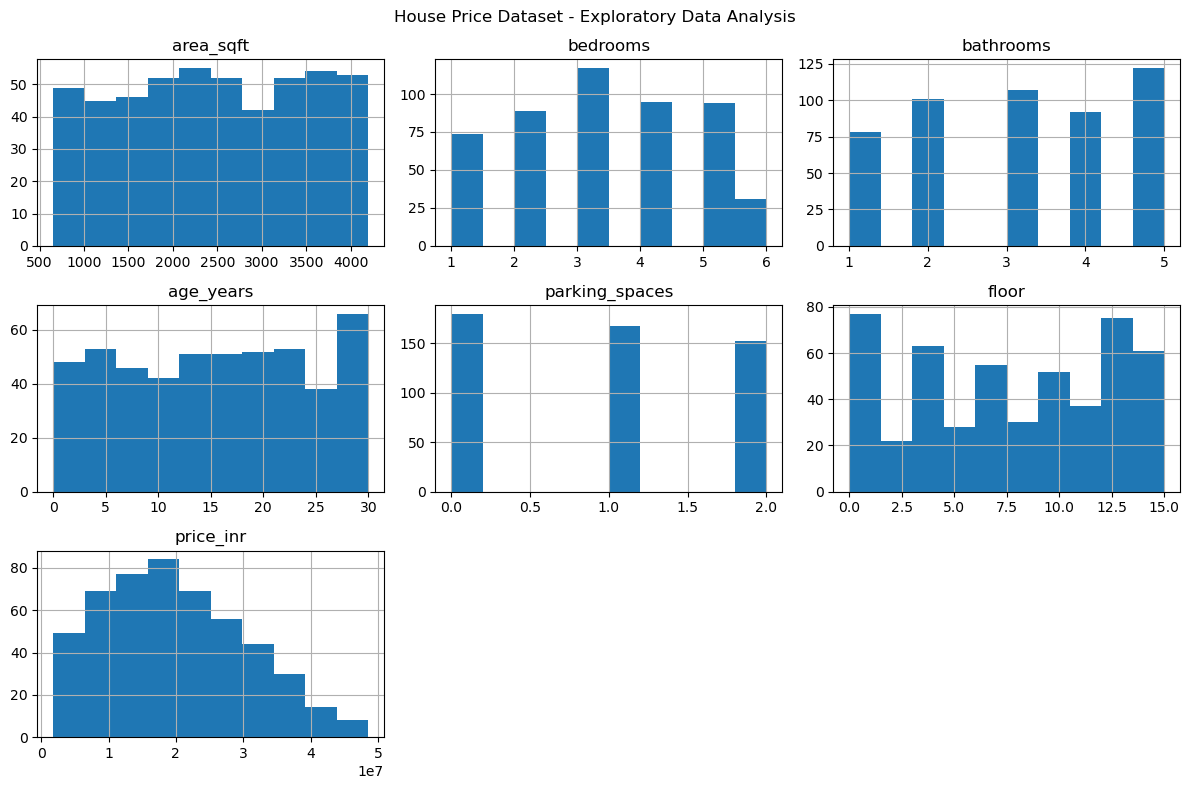

In [10]:
df.hist(figsize=(12, 8))
plt.suptitle("House Price Dataset - Exploratory Data Analysis")
plt.tight_layout()
plt.show()

In [11]:
# 4. Feature / target separation
X = df.drop(columns=["price_inr"])
y = df["price_inr"]

In [12]:
# 5. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

In [13]:
# 6. Preprocessing
categorical_features = ["location"]
numeric_features = [
    "area_sqft", "bedrooms", "bathrooms",
    "age_years", "parking_spaces", "floor"
]

In [14]:
preprocessor = ColumnTransformer([
    (
        "numeric",
        SimpleImputer(strategy="median"),
        numeric_features
    ),
    (
        "categorical",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]),
        categorical_features
    )
])

In [15]:
# 7. Regression model
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=18,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

In [16]:
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

In [17]:
# 8. Train
print("\nTraining model...")
pipeline.fit(X_train, y_train)


Training model...


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tra

In [18]:
# 9. Evaluation
predictions = pipeline.predict(X_test)

In [19]:
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

In [20]:
print("\n=== MODEL PERFORMANCE ===")
print(f"MAE  : Rs. {mae:,.2f}")
print(f"RMSE : Rs. {rmse:,.2f}")
print(f"R2   : {r2:.4f}")


=== MODEL PERFORMANCE ===
MAE  : Rs. 874,587.00
RMSE : Rs. 1,107,077.33
R2   : 0.9875


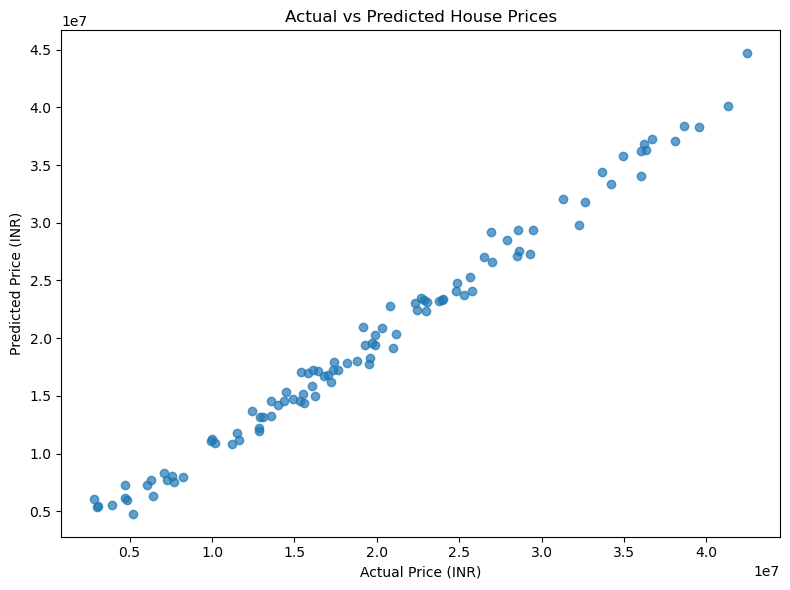

In [21]:
# 10. Actual vs predicted plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, alpha=0.7)
plt.xlabel("Actual Price (INR)")
plt.ylabel("Predicted Price (INR)")
plt.title("Actual vs Predicted House Prices")
plt.tight_layout()
plt.show()

In [22]:
# 11. Save trained model
joblib.dump(pipeline, MODEL_FILE)
print(f"\nModel saved as: {MODEL_FILE}")


Model saved as: house_price_model.joblib


In [23]:
# 12. Prediction interface
print("\n=== HOUSE PRICE PREDICTION INTERFACE ===")
print("Press Ctrl+C to exit.")


=== HOUSE PRICE PREDICTION INTERFACE ===
Press Ctrl+C to exit.


In [25]:
# 12. Prediction Interface

print("\n=== HOUSE PRICE PREDICTION INTERFACE ===")

try:
    location = input("Location: ")
    area_sqft = float(input("Area (sqft): "))
    bedrooms = int(input("Number of bedrooms: "))
    bathrooms = int(input("Number of bathrooms: "))
    age_years = int(input("Property age (years): "))
    parking_spaces = int(input("Parking spaces: "))
    floor = int(input("Floor number: "))

    new_house = pd.DataFrame([{
        "location": location,
        "area_sqft": area_sqft,
        "bedrooms": bedrooms,
        "bathrooms": bathrooms,
        "age_years": age_years,
        "parking_spaces": parking_spaces,
        "floor": floor
    }])

    predicted_price = pipeline.predict(new_house)[0]

    print("\n======================================")
    print(f"Predicted House Price: Rs. {predicted_price:,.0f}")
    print("======================================")

except ValueError:
    print("Please enter valid numbers for area, bedrooms, bathrooms, age, parking and floor.")

except KeyboardInterrupt:
    print("\nPrediction cancelled.")


=== HOUSE PRICE PREDICTION INTERFACE ===


Location:  trichy
Area (sqft):  3490
Number of bedrooms:  5
Number of bathrooms:  5
Property age (years):  5
Parking spaces:  0
Floor number:  15



Predicted House Price: Rs. 26,102,384
